In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
city_metrics = pd.read_csv('../data/clean/city_metrics_cities.csv')
city_metrics_national = pd.read_csv('../data/clean/city_metrics_national.csv')
rents_sales = pd.read_csv('../data/clean/rents_sales_cities.csv')
rents_sales_national = pd.read_csv('../data/clean/rents_sales_national.csv')
tom = pd.read_csv('../data/clean/etw_efh_tom_cities.csv')
tom_national = pd.read_csv('../data/clean/etw_efh_tom_cities_national.csv')
bb_volume = pd.read_csv('../data/clean/bundesbank_lending_volume.csv')
bb_rate_all = pd.read_csv('../data/clean/bundesbank_interest_rate_all.csv')
bb_rate_10yr = pd.read_csv('../data/clean/bundesbank_interest_rate_10yr_fixed.csv')

In [3]:
for name,df in [('city_metrics', city_metrics),('city_metrics_national', city_metrics_national), ('rents_sales', rents_sales),
                ('rents_sales_national',rents_sales_national), ('tom', tom), ('tom_national', tom_national), ('bb_volume', bb_volume), 
                ('bb_rate_all', bb_rate_all), ('bb_rate_10yr',bb_rate_10yr)]:
    print(name,df.shape)

city_metrics (18204, 13)
city_metrics_national (492, 13)
rents_sales (2704, 7)
rents_sales_national (134, 7)
tom (2736, 8)
tom_national (114, 8)
bb_volume (282, 3)
bb_rate_all (282, 3)
bb_rate_10yr (282, 3)


In [4]:
city_metrics_nominal = city_metrics[city_metrics['Inflation_adjusted']==0].copy()
city_metrics_real = city_metrics[city_metrics['Inflation_adjusted']==1].copy()

In [5]:
print(city_metrics_nominal.shape)
print(city_metrics_real.shape)

(9102, 13)
(9102, 13)


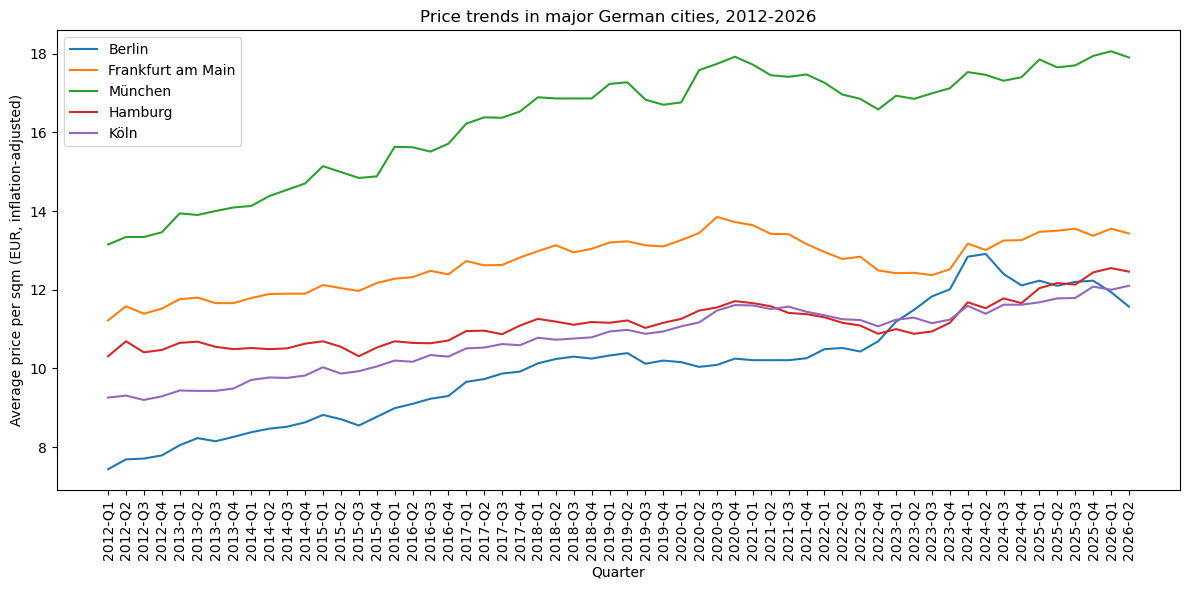

In [6]:
major_cities = ['Berlin','Frankfurt am Main', 'München', 'Hamburg', 'Köln']
chart_data = city_metrics_real[
    (city_metrics_real["Granularity"] == "quarterly") &
    (city_metrics_real["City"].isin(major_cities))
].copy()

chart_data["Period"] = chart_data["Year"].astype(str) + "-Q" + chart_data["Quarter"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
for city in major_cities:
    city_data = chart_data[chart_data["City"] == city].sort_values(["Year", "Quarter"])
    ax.plot(city_data["Period"], city_data["AVG_PRICE_SQM"], label=city)

ax.set_xlabel("Quarter")
ax.set_ylabel("Average price per sqm (EUR, inflation-adjusted)")
ax.set_title("Price trends in major German cities, 2012-2026")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Across the five major cities, prices rank consistently from highest to lowest: München, Frankfurt am Main, Hamburg, Köln, and Berlin. München's premium over the other four holds throughout the full 2012 to 2026 period, no crossovers occur in the ranking.

This shows absolute price level, not growth. Berlin ranking lowest here does not mean Berlin grew the slowest, a city can have low absolute prices while still growing quickly from that lower starting point. That is a separate question, taken up next by comparing cumulative growth rather than price level.

## Which cities grew the fastest?

Price level and price growth are different things. A city can be expensive without growing quickly, or grow quickly from a lower starting point. This section calculates cumulative growth for every city from 2012 to the most recent available data, using inflation-adjusted prices, so the comparison reflects real growth rather than growth inflated by general price rises across the economy.

In [9]:
quarterly_real = city_metrics_real[city_metrics_real["Granularity"] == "quarterly"].copy()

first_year = quarterly_real["Year"].min()
last_year = quarterly_real["Year"].max()

print(first_year, last_year)

2012 2026


In [10]:
first_period = quarterly_real.sort_values(["Year", "Quarter"]).groupby("City").first()["AVG_PRICE_SQM"]
last_period = quarterly_real.sort_values(["Year", "Quarter"]).groupby("City").last()["AVG_PRICE_SQM"]

growth = ((last_period - first_period) / first_period * 100).round(1)
growth_sorted = growth.sort_values(ascending=False)

print(growth_sorted)

City
Berlin               55.5
Augsburg             53.1
Leipzig              46.6
Lübeck               40.7
Potsdam              39.3
München              36.1
Kiel                 33.1
Hannover             32.9
Mönchengladbach      31.4
Köln                 30.7
Nürnberg             29.6
Münster              28.2
Dortmund             27.6
Bielefeld            26.9
Mannheim             26.5
Bremen               25.4
Rhein-Erft-Kreis     25.3
Stuttgart            25.1
Düsseldorf           24.9
Braunschweig         23.0
Dresden              21.4
Bochum               21.2
Karlsruhe            21.1
Hamburg              20.9
Wiesbaden            20.6
Essen                20.6
Duisburg             20.2
Bonn                 20.0
Frankfurt am Main    19.7
Erfurt               19.5
Hamm                 19.0
Wuppertal            18.3
Aachen               17.7
Bocholt              16.2
Kreis Mettmann       15.6
Gelsenkirchen        15.6
Chemnitz             -5.4
Name: AVG_PRICE_SQM, dtype: float

In [11]:
chemnitz_data = quarterly_real[quarterly_real["City"] == "Chemnitz"].sort_values(["Year", "Quarter"])
print(chemnitz_data[["Year", "Quarter", "AVG_PRICE_SQM"]])

       Year  Quarter  AVG_PRICE_SQM
241    2012      1.0           4.99
537    2012      2.0           5.01
833    2012      3.0           5.02
1129   2012      4.0           4.98
1499   2013      1.0           5.03
1795   2013      2.0           5.05
2091   2013      3.0           5.06
2387   2013      4.0           5.04
2757   2014      1.0           5.08
3053   2014      2.0           5.06
3349   2014      3.0           5.04
3645   2014      4.0           5.07
4015   2015      1.0           5.12
4311   2015      2.0           5.04
4607   2015      3.0           5.06
4903   2015      4.0           5.10
5273   2016      1.0           5.13
5569   2016      2.0           5.15
5865   2016      3.0           5.12
6161   2016      4.0           5.09
6531   2017      1.0           5.18
6827   2017      2.0           5.12
7123   2017      3.0           5.10
7419   2017      4.0           5.12
7789   2018      1.0           5.13
8085   2018      2.0           5.12
8381   2018      3.0        

## Growth reveals a different story than price level

Ranking cities by cumulative real growth rather than absolute price level tells a very different story than the first chart. Berlin, the lowest priced of the five major cities by level, actually grew the fastest of all 37 cities in the dataset at 55.5 percent from 2012 to 2026. München, the highest priced city by level, grew more slowly at 36.1 percent. Augsburg, a city outside the well known five, ranks second at 53.1 percent.

One city stands apart from the rest: Chemnitz is the only city in the dataset with negative growth, down 5.4 percent over the full period. Its quarterly price history shows a genuinely flat market from 2012 through 2021, followed by a real, sustained decline beginning in 2022 that continues through the most recent data. This is consistent with Chemnitz's position as a smaller eastern German city, a region that has generally seen weaker housing demand growth than western Germany's major cities since reunification.

In [13]:
rents_sales_quarterly = rents_sales[rents_sales["Granularity"] == "quarterly"].copy()
rents_sales_real = rents_sales_quarterly[rents_sales_quarterly["Inflation_adjusted"] == 1].copy()

first_rent = rents_sales_real.sort_values(["Year", "Quarter"]).groupby("City").first()["Rent_Index"]
last_rent = rents_sales_real.sort_values(["Year", "Quarter"]).groupby("City").last()["Rent_Index"]

first_sales = rents_sales_real.sort_values(["Year", "Quarter"]).groupby("City").first()["Sales_Index"]
last_sales = rents_sales_real.sort_values(["Year", "Quarter"]).groupby("City").last()["Sales_Index"]

rent_growth = ((last_rent - first_rent) / first_rent * 100).round(1)
sales_growth = ((last_sales - first_sales) / first_sales * 100).round(1)

comparison = pd.DataFrame({
    "Rent_growth_pct": rent_growth,
    "Sales_growth_pct": sales_growth,
})
comparison["Gap"] = (comparison["Sales_growth_pct"] - comparison["Rent_growth_pct"]).round(1)
comparison_sorted = comparison.sort_values("Gap", ascending=False)

print(comparison_sorted)

                   Rent_growth_pct  Sales_growth_pct    Gap
City                                                       
Rhein-Erft-Kreis              19.0             124.3  105.3
Potsdam                       29.2              99.0   69.8
Berlin                        48.0             112.0   64.0
Bonn                          14.8              74.8   60.0
Leipzig                       33.6              92.8   59.2
Köln                          22.1              81.1   59.0
Frankfurt am Main             15.2              68.0   52.8
Dresden                       16.4              65.9   49.5
Kreis Mettmann                13.8              62.8   49.0
Münster                       19.6              68.1   48.5
Dortmund                      22.8              71.3   48.5
Stuttgart                     19.1              64.3   45.2
Düsseldorf                    18.8              63.4   44.6
Hamburg                        9.1              52.5   43.4
Karlsruhe                     14.5      

In [14]:
rek_data = rents_sales_real[rents_sales_real["City"] == "Rhein-Erft-Kreis"].sort_values(["Year", "Quarter"])
print(rek_data[["Year", "Quarter", "Rent_Index", "Sales_Index"]])

      Year  Quarter  Rent_Index  Sales_Index
33    2012      1.0   97.288491    78.147209
71    2012      2.0   96.140280    81.622177
109   2012      3.0   96.143605    83.235237
147   2012      4.0   96.106960    82.408081
227   2013      1.0   96.858281    80.033524
265   2013      2.0   96.640613    88.500740
303   2013      3.0   96.829794    83.854576
341   2013      4.0   95.895854    85.334549
423   2014      1.0   96.878794    84.227356
463   2014      2.0   98.470282    90.255188
503   2014      3.0   98.769109    92.500435
543   2014      4.0   98.857071    98.356056
627   2015      1.0   99.813599    91.687111
667   2015      2.0   99.457505   100.399773
707   2015      3.0  100.015335   100.832031
747   2015      4.0  100.713873   107.081085
831   2016      1.0  102.100834   108.968216
871   2016      2.0  102.697862   110.956139
911   2016      3.0  102.594722   112.565445
951   2016      4.0  103.624284   107.751793
1035  2017      1.0  103.858645   112.110390
1075  2017

Rhein-Erft-Kreis shows the widest rent-versus-price divergence in the dataset. Its quarterly history confirms this is a genuine, sustained pattern rather than a data artifact: rent climbed slowly and steadily from an index of about 97 in 2012 to about 115 by 2025, while the sales index rose far more steeply over the same period, peaking above 200 in 2021 before a partial pullback. The gap between the two never closes, sale prices remain well above rent growth throughout the full period.

Add EDA notebook: city price growth and rent vs price divergence

Analyzed real (inflation-adjusted) price growth across all 37 GREIX cities.
Berlin grew fastest at 55.5 percent from 2012 to 2026, despite ranking
lowest in absolute price among major cities. Chemnitz was the only city
with negative growth, down 5.4 percent, traced to a sustained decline
starting in 2022.

Compared rent growth against sale price growth per city using the same
method. Every city shows sales outpacing rent. Rhein-Erft-Kreis shows
the widest gap at 105.3 percentage points, verified against its full
quarterly history to confirm the divergence is a genuine sustained
trend rather than a data artifact.

## Market liquidity: houses vs. apartments

This section looks at TOM_4q, the average number of days a listing stays on the market before selling, measured as a rolling 4 quarter average. Comparing EFH (single family houses) against ETW (apartments) shows whether one type of property sells faster than the other, and whether that gap has changed over the 2012 to 2026 period.

In [18]:
tom_by_year_segment = tom.groupby(['Year', 'Segment'])['TOM_4q'].mean().round(1).unstack()
print(tom_by_year_segment)

Segment   EFH    ETW
Year                
2012     84.6   86.4
2013     97.7  102.2
2014     92.3   97.6
2015     85.9   89.6
2016     78.6   86.8
2017     77.6   82.9
2018     73.3   79.0
2019     75.0   80.3
2020     69.4   75.1
2021     62.2   69.2
2022     62.7   71.0
2023     85.6   89.8
2024     99.0  110.5
2025     90.8   94.3
2026     90.3   88.1


Houses (EFH) consistently sell faster than apartments (ETW) across nearly the entire period, TOM stays lower for EFH in every year from 2012 through 2025. The market also shows a clear cycle: time on market fell steadily from the mid 80s and 90s in 2012 to 2014 down to a low of about 62 days in 2021, then rose sharply back up to around 99 to 110 days by 2024, before easing slightly in 2025. This pattern, a tightening market through the late 2010s followed by a sharp slowdown starting around 2022, lines up in timing with rising interest rates, worth testing directly against the Bundesbank data next.

2026 shows EFH slightly higher than ETW for the only time in the dataset, but this year only has one quarter of data so far and should not be read as a reversal of the broader pattern yet.

## Does liquidity track financing conditions?

The TOM trend just shown looks like it might follow interest rates, tightening while rates were low, slowing down as rates rose. This section checks that directly by lining up the national TOM average against the Bundesbank interest rate series, year by year.

In [34]:
tom_by_year = tom.groupby("Year")["TOM_4q"].mean().round(1)

bb_rate_all["Year"] = bb_rate_all["Date"].str[:4].astype(int)
rate_by_year = bb_rate_all.groupby("Year")["Interest_rate"].mean().round(2)

liquidity_vs_rate = pd.DataFrame({
    "Avg_TOM_days": tom_by_year,
    "Avg_interest_rate": rate_by_year,
}).dropna()

print(liquidity_vs_rate)

      Avg_TOM_days  Avg_interest_rate
Year                                 
2012          85.5               3.07
2013         100.0               2.76
2014          95.0               2.50
2015          87.8               1.95
2016          82.7               1.76
2017          80.2               1.83
2018          76.2               1.87
2019          77.6               1.52
2020          72.3               1.25
2021          65.7               1.26
2022          66.9               2.52
2023          87.7               4.00
2024         104.7               3.80
2025          92.5               3.67
2026          89.2               3.83


Market liquidity and interest rates move together closely across the full period. Both fall in tandem from 2012 to 2021, reaching their lowest points in the same year, rates at 1.26 percent and TOM at 65.7 days. When rates begin rising sharply in 2022, TOM does not respond immediately, it only shows a small increase that year. The larger jump in TOM comes in 2023 and peaks in 2024, roughly a one year lag behind the rate increase. This suggests the housing market absorbs financing shocks with a delay rather than reacting to them instantly, a pattern worth noting rather than assuming liquidity tracks rates in perfect lockstep.

## Nominal vs. real growth: does the ranking change?

Every price observation exists in two versions, nominal and inflation-adjusted. This section compares both growth rankings side by side to see whether a city's position changes depending on which version you use, and by how much.

In [38]:
quarterly_nominal = city_metrics_nominal[city_metrics_nominal["Granularity"] == "quarterly"].copy()

first_nom = quarterly_nominal.sort_values(["Year", "Quarter"]).groupby("City").first()["AVG_PRICE_SQM"]
last_nom = quarterly_nominal.sort_values(["Year", "Quarter"]).groupby("City").last()["AVG_PRICE_SQM"]
growth_nominal = ((last_nom - first_nom) / first_nom * 100).round(1)

nominal_vs_real = pd.DataFrame({
    "Nominal_growth_pct": growth_nominal,
    "Real_growth_pct": growth,
})
nominal_vs_real["Inflation_effect"] = (nominal_vs_real["Nominal_growth_pct"] - nominal_vs_real["Real_growth_pct"]).round(1)

nominal_vs_real["Nominal_rank"] = nominal_vs_real["Nominal_growth_pct"].rank(ascending=False).astype(int)
nominal_vs_real["Real_rank"] = nominal_vs_real["Real_growth_pct"].rank(ascending=False).astype(int)
nominal_vs_real["Rank_shift"] = nominal_vs_real["Nominal_rank"] - nominal_vs_real["Real_rank"]

print(nominal_vs_real.sort_values("Real_rank"))

                   Nominal_growth_pct  Real_growth_pct  Inflation_effect  \
City                                                                       
Berlin                          113.0             55.5              57.5   
Augsburg                        109.8             53.1              56.7   
Leipzig                         101.0             46.6              54.4   
Lübeck                           92.3             40.7              51.6   
Potsdam                          90.9             39.3              51.6   
München                          86.4             36.1              50.3   
Kiel                             82.6             33.1              49.5   
Hannover                         82.3             32.9              49.4   
Mönchengladbach                  79.8             31.4              48.4   
Köln                             79.1             30.7              48.4   
Nürnberg                         77.5             29.6              47.9   
Münster     

Comparing nominal and real growth side by side shows the city ranking is remarkably stable. Out of 37 cities, only Bochum and Karlsruhe swap places, a single rank position, everything else holds exactly the same order in both nominal and real terms.

What changes is the scale, not the order. Nominal growth runs roughly 44 to 57 percentage points higher than real growth for almost every city, meaning close to half of the headline nominal growth in this dataset reflects general inflation rather than a genuine increase in housing value. Berlin's 113 percent nominal growth becomes 55.5 percent once inflation is stripped out, still the highest in the dataset, but a materially different number to quote.

This consistency across cities means inflation affected the German housing market broadly evenly over this period, rather than distorting some cities more than others, which is why picking nominal or real growth changes the story you tell about scale, but not which cities are actually leading or lagging.